# The same number, counted two ways

**Artifact `art__tq3ZgPRYB0B` — a pure-reanalysis EVALUATION.** Zero GPU, zero generation,
zero LLM/API spend (`cost_usd = 0.0`), no downloads, no `torch`.

The draft paper reports the correlation between a cheap benchmark-free safety score
(*our-AMS sigma*) and the judged plain-harmful refusal rate as **0.358** in one section and
**0.821** in another. Those are **the same statistic at two different aggregation units** —
19 model *checkpoints* (members) against 7 lineage-aggregated units — and neither section
names its unit.

This notebook reproduces the core of the evaluation on the frozen panel:

1. **Reproduction gate** — recompute the archived reference numbers from the frozen panel
   and check them to `1e-6`.
2. **Analysis 1, the dual aggregation (H-U repair)** — every score at BOTH units under an
   analysis-choice grid, with lineage-clustered bootstrap CIs, the exhaustive `7! = 5040`
   lineage permutation p and its corrected floor `1/5040`, a leave-one-lineage-out
   jackknife, an ICC decomposition of *why* the two units differ, and the paired oriented
   Delta at both units.
3. **A visualisation** of how far the aggregation unit alone moves the correlation.

The estimator code (`orient`, `spearman_basic`, `clustered_bootstrap_rho`,
`lineage_permutation_p`, `loo_lineage_jackknife`, `paired_rho_delta_clustered`,
`auc_binary`, `disattenuate`) is copied **verbatim** from the frozen archive's
`lib_iter3/statsx.py`, and the panel helpers (`sentinel_value`, `column_values`,
`lineage_units`) verbatim from `stage0_ingest.py` — definitions do not drift.

In [1]:
# --- Install dependencies -------------------------------------------------
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# numpy / scipy / pandas / matplotlib are pre-installed on Colab: install locally ONLY,
# at Colab's exact versions (installing them ON Colab corrupts the loaded C extensions).
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'scipy==1.16.3', 'pandas==2.2.2', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
# --- Imports (as in the original scripts, plus matplotlib/pandas for the demo) ---
from __future__ import annotations

import itertools
import json
import math
import os

import numpy as np
from scipy.stats import rankdata, spearmanr

import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# --- Data loading (GitHub raw URL, with a local fallback) -----------------
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-c9546e-rating-model-safety-in-eighty-forward-pa/main/round-4/evaluation-1/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(data["description"])
print()
print("panel rows        :", len(data["panel_rows"]))
print("lineages          :", sorted({r["lineage"] for r in data["panel_rows"]}))
print("archived ref legs :", len(data["archived_reference_values"]))

Mini demo subset of the frozen 19-member / 7-lineage safety-score panel used by the dual-aggregation re-analysis (art__tq3ZgPRYB0B).

panel rows        : 19
lineages          : ['L1', 'L2', 'L3', 'L4', 'L5', 'L6', 'L7']
archived ref legs : 11


## Configuration

Every tunable knob of the demo lives here. The only genuinely expensive one is the number of
bootstrap replicates: the original evaluation uses `N_BOOT = 5000` (the plan's replicate
count; the archive's own default is 10000). The exhaustive lineage permutation is **not**
tunable — it enumerates all `7! = 5040` lineage assignments by construction, which is the
whole point of the corrected floor `1/5040`.

In [5]:
# =========================== CONFIG =======================================
N_BOOT = 5000          # bootstrap replicates. ORIGINAL (common.py): 5000. Archive default: 10000.
BOOT_SEED = 20260812   # sx.BOOT_SEED, frozen

# The 8 score columns of the panel (common.py: SCORE_COLUMNS). Use all of them.
SCORE_COLUMNS = [
    "alpha_50_logistic",
    "alpha_50_nonparametric",
    "max_refusal_rate",
    "ams_sigma",
    "ams_sigma_para",
    "ams_sigma_archive",
    "logit_gap_benign",
    "logit_gap_harmful",
]

# Only the two PRIMARY analysis-choice cells get the full statistic set (CI, permutation,
# jackknife, AUC, ICC); the original grid has four further rho-only sensitivity configs.
PRIMARY_ONLY = True

# reliability of the judged outcome, used for the disattenuation factor (statsx.py)
JUDGE_SELF_AGREEMENT_FROZEN = 0.75
JUDGE_SELF_AGREEMENT_REPAIRED = 0.9597

TOL = 1e-6             # reproduction-gate tolerance
# ==========================================================================

SCORE_LABEL = {
    "alpha_50_logistic": "alpha_50 (logistic)",
    "alpha_50_nonparametric": "alpha_50 (non-parametric)",
    "max_refusal_rate": "max refusal rate (alpha_50 surrogate)",
    "ams_sigma": "our-AMS sigma",
    "ams_sigma_para": "our-AMS sigma (paraphrase refit)",
    "ams_sigma_archive": "our-AMS sigma (archived)",
    "logit_gap_benign": "logit-gap (benign)",
    "logit_gap_harmful": "logit-gap (harmful)",
}

rows = data["panel_rows"]
orient_by_col = data["score_column_orientation"]
print("N_BOOT =", N_BOOT, "| scores =", len(SCORE_COLUMNS), "| members =", len(rows))

N_BOOT = 5000 | scores = 8 | members = 19


## The archived estimator library (`lib_iter3/statsx.py`, verbatim)

Sign-oriented, lineage-clustered statistics. Everything operates on ORIENTED scores
(higher = safer) with the raw unoriented form reported alongside. **The resampling /
permutation unit is the LINEAGE, never the member** — members within a lineage are not
independent, so a member-level permutation over `19!` would be an invalid null.

The permutation function is where the corrected floor comes from: with unequal lineage
sizes only the identity permutation is guaranteed to reproduce `|rho|`, so the attainable
floor is `1/K!`, not the conventional `2/K!`.

In [6]:
def orient(values, sign: int):
    return [None if v is None else sign * float(v) for v in values]


def _clean(x, y):
    idx = [i for i, (a, b) in enumerate(zip(x, y))
           if a is not None and b is not None
           and np.isfinite(float(a)) and np.isfinite(float(b))]
    return (np.array([float(x[i]) for i in idx]),
            np.array([float(y[i]) for i in idx]), idx)


def _rho(a, b):
    if a.size < 3 or np.allclose(a, a[0]) or np.allclose(b, b[0]):
        return None
    r = spearmanr(a, b).statistic
    return None if (r is None or not np.isfinite(r)) else float(r)


def spearman_basic(x, y) -> dict:
    a, b, idx = _clean(x, y)
    if a.size < 3:
        return {"rho": None, "p_asymptotic": None, "n": int(a.size)}
    rho = _rho(a, b)
    p = float(spearmanr(a, b).pvalue) if rho is not None else None
    return {"rho": rho, "p_asymptotic": p, "n": int(a.size)}


# --------------------------------------------------------------------------
# Lineage-clustered bootstrap
# --------------------------------------------------------------------------
def clustered_bootstrap_rho(x, y, lineages, n_boot: int = N_BOOT,
                            seed: int = BOOT_SEED) -> dict:
    '''Resample LINEAGE IDs with replacement, take ALL members of each draw.'''
    a, b, idx = _clean(x, y)
    lin = [lineages[i] for i in idx]
    uniq = sorted(set(lin))
    by_lin = {L: [j for j, v in enumerate(lin) if v == L] for L in uniq}
    point = _rho(a, b)
    rng = np.random.default_rng(seed)
    boot = []
    for _ in range(n_boot):
        pick = rng.integers(0, len(uniq), size=len(uniq))
        sel = []
        for k in pick:
            sel.extend(by_lin[uniq[k]])
        if len(sel) < 3:
            continue
        r = _rho(a[sel], b[sel])
        if r is not None:
            boot.append(r)
    ci = ([float(np.percentile(boot, 2.5)), float(np.percentile(boot, 97.5))]
          if len(boot) >= 50 else None)
    return {"rho": point, "n": int(a.size), "n_lineages": len(uniq),
            "ci95_lineage_clustered": ci, "n_boot_valid": len(boot),
            "resampling_unit": "lineage label (L1..L7)"}

In [7]:
# --------------------------------------------------------------------------
# Exhaustive permutation over LINEAGE label assignments
# --------------------------------------------------------------------------
def lineage_permutation_p(x, y, lineages, max_exact_factorial: int = 40320,
                          n_random: int = 100000, seed: int = BOOT_SEED) -> dict:
    '''Permute which lineage's y-block is paired with which lineage's x-block.

    With unequal lineage sizes a permutation pi maps lineage L (size n_L) onto
    lineage pi(L) (size m); member j of L is paired with member (j mod m) of
    pi(L). This is deterministic, exhaustively enumerable over |lineages|!, and
    keeps the CLUSTER, not the member, as the exchangeable unit. The identity
    permutation is included and always reproduces |rho|, so the attainable floor
    is 1/K, not the 2/K that a reversal-symmetric permutation set would give.
    '''
    a, b, idx = _clean(x, y)
    lin = [lineages[i] for i in idx]
    uniq = sorted(set(lin))
    n_l = len(uniq)
    blocks = {L: [j for j, v in enumerate(lin) if v == L] for L in uniq}
    rho = _rho(a, b)
    if rho is None or n_l < 3:
        return {"rho": rho, "n_lineages": n_l, "p_permutation": None,
                "p_min_achievable": None, "exhaustive": False}
    ra = rankdata(a)
    rb = rankdata(b)

    def _perm_rho(perm):
        yy = np.empty_like(rb)
        for src_i, L in enumerate(uniq):
            tgt = blocks[uniq[perm[src_i]]]
            for j, member in enumerate(blocks[L]):
                yy[member] = rb[tgt[j % len(tgt)]]
        return _rho(ra, yy)

    nfac = math.factorial(n_l)
    if nfac <= max_exact_factorial:
        cnt = 0
        for perm in itertools.permutations(range(n_l)):
            r = _perm_rho(perm)
            if r is not None and abs(r) >= abs(rho) - 1e-12:
                cnt += 1
        # The identity permutation is always counted (it reproduces rho exactly),
        # so the smallest attainable count is 1 and the floor is 1/nfac. The
        # conventional 2/nfac assumes the permutation set is symmetric under
        # reversal, which a CLUSTER permutation with unequal block sizes does not
        # guarantee; both are reported so no p is ever quoted below its floor.
        return {"rho": rho, "n_lineages": n_l, "p_permutation": cnt / nfac,
                "p_min_achievable": 1.0 / nfac,
                "p_min_two_sided_symmetric_reference": 2.0 / nfac,
                "exhaustive": True,
                "n_permutations": nfac, "n_extreme": cnt}
    rng = np.random.default_rng(seed)
    cnt = 0
    for _ in range(n_random):
        r = _perm_rho(list(rng.permutation(n_l)))
        if r is not None and abs(r) >= abs(rho) - 1e-12:
            cnt += 1
    return {"rho": rho, "n_lineages": n_l, "p_permutation": (cnt + 1) / (n_random + 1),
            "p_min_achievable": 1.0 / (n_random + 1), "exhaustive": False,
            "n_permutations": n_random, "n_extreme": cnt}


# --------------------------------------------------------------------------
# Leave-one-lineage-out jackknife
# --------------------------------------------------------------------------
def loo_lineage_jackknife(x, y, lineages) -> dict:
    a, b, idx = _clean(x, y)
    lin = [lineages[i] for i in idx]
    uniq = sorted(set(lin))
    folds = []
    for L in uniq:
        keep = [j for j, v in enumerate(lin) if v != L]
        r = _rho(a[keep], b[keep]) if len(keep) >= 3 else None
        folds.append({"dropped_lineage": L, "n_remaining": len(keep), "rho": r})
    vals = [f["rho"] for f in folds if f["rho"] is not None]
    signs = {int(np.sign(v)) for v in vals if abs(v) > 1e-12}
    return {
        "n_folds": len(uniq), "folds": folds,
        "rho_full": _rho(a, b),
        "range": [float(min(vals)), float(max(vals))] if vals else None,
        "spread": float(max(vals) - min(vals)) if vals else None,
        "sign_stable": (len(signs) <= 1) if vals else None,
        "n_valid_folds": len(vals),
    }

In [8]:
# --------------------------------------------------------------------------
# Paired bootstrap of (rho_score - rho_reference) on the SAME lineage draws
# --------------------------------------------------------------------------
def paired_rho_delta_clustered(score, reference, y, lineages,
                               n_boot: int = N_BOOT, seed: int = BOOT_SEED) -> dict:
    idx = [i for i in range(len(y))
           if score[i] is not None and reference[i] is not None and y[i] is not None]
    if len(idx) < 3:
        return {"n": len(idx), "delta": None, "ci95": None,
                "rho_score": None, "rho_reference": None}
    a = np.array([float(score[i]) for i in idx])
    c = np.array([float(reference[i]) for i in idx])
    b = np.array([float(y[i]) for i in idx])
    lin = [lineages[i] for i in idx]
    uniq = sorted(set(lin))
    by_lin = {L: [j for j, v in enumerate(lin) if v == L] for L in uniq}
    ra, rc = _rho(a, b), _rho(c, b)
    delta = (ra - rc) if (ra is not None and rc is not None) else None
    rng = np.random.default_rng(seed)
    boot = []
    for _ in range(n_boot):
        pick = rng.integers(0, len(uniq), size=len(uniq))
        sel = []
        for k in pick:
            sel.extend(by_lin[uniq[k]])
        if len(sel) < 3:
            continue
        r1, r2 = _rho(a[sel], b[sel]), _rho(c[sel], b[sel])
        if r1 is not None and r2 is not None:
            boot.append(r1 - r2)
    ci = ([float(np.percentile(boot, 2.5)), float(np.percentile(boot, 97.5))]
          if len(boot) >= 50 else None)
    return {
        "n": len(idx), "n_lineages": len(uniq),
        "rho_score": ra, "rho_reference": rc, "delta": delta, "ci95": ci,
        "prob_delta_gt_0": float(np.mean(np.asarray(boot) > 0)) if boot else None,
        "n_boot_valid": len(boot),
        "verdict": (None if delta is None or ci is None else
                    ("SCORE_BETTER" if ci[0] > 0 else
                     ("REFERENCE_BETTER" if ci[1] < 0 else "TIE_CI_INCLUDES_0"))),
    }


# --------------------------------------------------------------------------
# Sign-free companion: AUC of the oriented score for y >= median(y)
# --------------------------------------------------------------------------
def auc_binary(score, y) -> dict:
    a, b, _ = _clean(score, y)
    if a.size < 4:
        return {"auc": None, "n": int(a.size)}
    med = float(np.median(b))
    lab = (b >= med).astype(int)
    if lab.sum() in (0, lab.size):
        return {"auc": None, "n": int(a.size), "note": "degenerate split"}
    r = rankdata(a)
    n1 = int(lab.sum())
    n0 = int(lab.size - n1)
    auc = (r[lab == 1].sum() - n1 * (n1 + 1) / 2) / (n1 * n0)
    return {"auc": float(auc), "n": int(a.size), "n_pos": n1, "n_neg": n0,
            "threshold": med, "outcome": "y_refusal >= median"}


def disattenuate(rho, reliability: float):
    if rho is None or reliability <= 0:
        return None
    return float(rho / math.sqrt(reliability))

## Panel helpers (`stage0_ingest.py`, verbatim)

Two conventions for an UNDEFINED score cell coexist in the archives, and the choice matters:

* `drop_undefined` — leave the cell out (iteration-3 experiment-1's convention);
* `rank_bottom` — substitute the sentinel `max(defined) + 1` for a negatively-oriented score
  (`min(defined) - 1` for a positive one), i.e. rank the member BOTTOM on safety. This is
  V2's pre-registered fallback, recovered from `V2/eval_a34.py`. **Without it V2's headline
  does not reproduce.**

`lineage_units` is the aggregation itself: one unit per lineage, the arithmetic MEAN over
that lineage's DEFINED members of both x and y.

In [9]:
def sentinel_value(rows, col: str, orientation: int):
    '''V2's pre-registered UNDEFINED fallback: rank an undefined member BOTTOM
    on safety by substituting max(defined)+1 for a negatively-oriented score
    (min(defined)-1 for a positively-oriented one).'''
    vals = [float(r[col]) for r in rows if r.get(col) is not None]
    if not vals:
        return None
    return (max(vals) + 1.0) if orientation < 0 else (min(vals) - 1.0)


def column_values(rows, col: str, orientation: int,
                  convention: str = "drop_undefined"):
    '''`drop_undefined` leaves UNDEFINED cells as None (E3's convention);
    `rank_bottom` substitutes the sentinel (V2's convention).'''
    if convention == "drop_undefined":
        return [None if r.get(col) is None else float(r[col]) for r in rows]
    if convention == "rank_bottom":
        s = sentinel_value(rows, col, orientation)
        return [s if r.get(col) is None else float(r[col]) for r in rows]
    raise ValueError(f"unknown definedness convention {convention!r}")


def lineage_units(rows, col: str, ycol: str = "y_e3",
                  reliable_only: bool = False, orientation: int = -1,
                  convention: str = "drop_undefined") -> dict:
    '''One unit per lineage: the MEAN over that lineage's DEFINED members of
    both x and y. A lineage with zero defined members drops out.'''
    xs = column_values(rows, col, orientation, convention)
    by_lin = {}
    for r, xv in zip(rows, xs):
        if reliable_only and r["unreliable"]:
            continue
        if xv is None or r.get(ycol) is None:
            continue
        rr = dict(r)
        rr["_x"] = xv
        by_lin.setdefault(r["lineage"], []).append(rr)
    units = []
    for lin in sorted(by_lin):
        mem = by_lin[lin]
        units.append({
            "lineage": lin,
            "n_members": len(mem),
            "members": [m["member_id"] for m in mem],
            "x": float(np.mean([float(m["_x"]) for m in mem])),
            "y": float(np.mean([float(m[ycol]) for m in mem])),
        })
    return {"units": units, "n_units": len(units),
            "definedness_convention": convention,
            "reliable_only": reliable_only, "outcome_column": ycol,
            "aggregation_function": "arithmetic mean over the lineage's DEFINED members",
            "n_members_used": sum(u["n_members"] for u in units),
            "dropped_lineages": sorted(
                {r["lineage"] for r in rows} - {u["lineage"] for u in units})}

## The frozen panel

19 checkpoints ("members") grouped into 7 lineages. `y_e3` / `y_v2` are the judged
plain-harmful refusal rate as transcribed by the two archives — they disagree on 3 of the 19
members, all of which are UNRELIABLE-excluded, so no reported correlation moves (this was
DISCOVERED by the evaluation, not inherited).

In [10]:
panel = pd.DataFrame(rows)[[
    "member_id", "lineage", "level", "n_layers", "y_e3", "y_v2", "unreliable",
    "alpha_50_status", "max_refusal_rate", "alpha_50_nonparametric",
    "ams_sigma", "logit_gap_harmful",
]]
print(panel.to_string(index=False))
print()
print("members per lineage:",
      {L: sum(1 for r in rows if r["lineage"] == L) for L in sorted({r["lineage"] for r in rows})})
print("UNRELIABLE-excluded:", sum(1 for r in rows if r["unreliable"]), "of", len(rows))
print("alpha_50 status breakdown:",
      pd.Series([r["alpha_50_status"] for r in rows]).value_counts().to_dict())

     member_id lineage       level  n_layers   y_e3    y_v2  unreliable               alpha_50_status  max_refusal_rate  alpha_50_nonparametric  ams_sigma  logit_gap_harmful
   l1_instruct      L1    instruct        28 0.3125 0.31250       False       UNRELIABLE_NON_MONOTONE              0.97                0.447368   2.976479          -4.625576
l1_abliterated      L1 abliterated        28 0.1125 0.11250       False       UNRELIABLE_NON_MONOTONE              0.98                0.557143   2.008705         -10.161225
       l1_base      L1        base        28 0.1500 0.19375        True UNDEFINED_MAX_RATE_BELOW_HALF              0.00                     NaN   1.501771          -2.584037
   l6_instruct      L6    instruct        32 0.2500 0.25000       False   UNDEFINED_NONPOSITIVE_SLOPE              0.81                0.242424   2.286257          -1.511675
       l6_base      L6        base        32 0.4875 0.48750       False UNDEFINED_MAX_RATE_BELOW_HALF              0.13           

## Reproduction gate

Before restating any archived number, recompute it from the frozen panel and check it to
`1e-6`. The demo runs the 8 numeric legs that the panel alone determines: the four
discrimination-matrix rows (member level, all 19), the AMS paraphrase refit, and V2's three
lineage-level values (14 reliable members, `rank_bottom`, `y_v2`).

In [11]:
REF = data["archived_reference_values"]
legs = []

def leg(name, recomputed, tol=TOL):
    archived = REF[name]
    ok = recomputed is not None and abs(float(recomputed) - float(archived)) <= tol
    legs.append({"leg": name, "archived": archived, "recomputed": recomputed,
                 "abs_delta": None if recomputed is None else abs(float(recomputed) - float(archived)),
                 "pass": bool(ok)})

# --- E3's discrimination-matrix rows: member level, all 19, drop_undefined, y_e3
def member_rho(col, ycol="y_e3", reliable_only=False, convention="drop_undefined"):
    sel = [r for r in rows if not (reliable_only and r["unreliable"])]
    sign = orient_by_col[col]
    xs = column_values(sel, col, sign, convention)
    ys = [r[ycol] for r in sel]
    return spearman_basic(orient(xs, sign), ys)["rho"]

leg("e3_rho_oriented_alpha_50_row", member_rho("max_refusal_rate"))
leg("e3_rho_oriented_our_AMS_row", member_rho("ams_sigma"))
leg("e3_rho_oriented_logit_gap_benign_row", member_rho("logit_gap_benign"))
leg("e3_rho_oriented_logit_gap_harmful_row", member_rho("logit_gap_harmful"))
leg("e3_rho_oriented_ams_paraphrase_refit", member_rho("ams_sigma_para"))

# --- V2's lineage-level values: 14 reliable members, rank_bottom sentinel, y_v2
def lineage_rho(col):
    sign = orient_by_col[col]
    lu = lineage_units(rows, col, ycol="y_v2", reliable_only=True,
                       orientation=sign, convention="rank_bottom")
    xs = [u["x"] for u in lu["units"]]
    ys = [u["y"] for u in lu["units"]]
    return spearman_basic(orient(xs, sign), ys)["rho"]

r_a50 = lineage_rho("alpha_50_nonparametric")
r_ams = lineage_rho("ams_sigma")
leg("v2_lineage_rho_alpha50", r_a50)
leg("v2_lineage_rho_ourAMS", r_ams)
leg("v2_lineage_oriented_delta", r_a50 - r_ams)

gate = pd.DataFrame(legs)
print(gate.to_string(index=False))
n_failed = int((~gate["pass"]).sum())
print(f"\nREPRODUCTION GATE: {len(legs) - n_failed}/{len(legs)} PASS to {TOL}"
      f"  ->  {'PASSED' if n_failed == 0 else 'FAILED'}")

                                  leg  archived  recomputed  abs_delta  pass
         e3_rho_oriented_alpha_50_row -0.208095   -0.208095        0.0  True
          e3_rho_oriented_our_AMS_row  0.357803    0.357803        0.0  True
 e3_rho_oriented_logit_gap_benign_row  0.101099    0.101099        0.0  True
e3_rho_oriented_logit_gap_harmful_row  0.667254    0.667254        0.0  True
 e3_rho_oriented_ams_paraphrase_refit  0.654068    0.654068        0.0  True
               v2_lineage_rho_alpha50 -0.107143   -0.107143        0.0  True
                v2_lineage_rho_ourAMS  0.821429    0.821429        0.0  True
            v2_lineage_oriented_delta -0.928571   -0.928571        0.0  True

REPRODUCTION GATE: 8/8 PASS to 1e-06  ->  PASSED


## Analysis 1 — dual aggregation (the H-U repair)

The analysis-choice grid separates the three things conflated in the 0.358 / 0.821 gap: the
**aggregation unit**, the **UNRELIABLE exclusion**, and the **UNDEFINED convention**. The
two `primary` cells reproduce the two archived rows:

| config | reproduces |
|---|---|
| `all19_drop_undefined_yE3` | E3's discrimination-matrix row (member level) |
| `reliable14_rank_bottom_yV2` | V2's oriented-Delta evaluation (lineage level) |

`cell()` below is the per-cell statistic set, copied from `stage1_dual.py`: oriented rho,
lineage-clustered bootstrap CI (suppressed at `n_lineages <= 3` — a bootstrap over 3 numbers
is not an interval), the exhaustive lineage permutation p with its floor, an
orientation-free AUC comparator, the leave-one-lineage-out jackknife and the disattenuated
rho.

In [12]:
ALPHA50_ROW_COLUMN = "max_refusal_rate"          # E3's alpha_50 row carrier
ALPHA50_V2_COLUMN = "alpha_50_nonparametric"     # V2's alpha_50 row carrier
AMS_COLUMN = "ams_sigma"

# The analysis-choice grid. `primary` cells get the full statistic set; the
# others are reported as a rho-only sensitivity surface.
CONFIGS = [
    {"id": "all19_drop_undefined_yE3", "reliable_only": False,
     "convention": "drop_undefined", "ycol": "y_e3", "primary": True,
     "label": "all 19 members / UNDEFINED dropped / outcome as transcribed by E3",
     "reproduces": "E3's discrimination-matrix row (member level)"},
    {"id": "reliable14_rank_bottom_yV2", "reliable_only": True,
     "convention": "rank_bottom", "ycol": "y_v2", "primary": True,
     "label": "14 reliable members / UNDEFINED ranked bottom / outcome from V2's member table",
     "reproduces": "V2's oriented-Delta evaluation (lineage level)"},
    {"id": "all19_rank_bottom_yE3", "reliable_only": False,
     "convention": "rank_bottom", "ycol": "y_e3", "primary": False,
     "label": "all 19 members / UNDEFINED ranked bottom / E3 outcome", "reproduces": None},
    {"id": "reliable14_drop_undefined_yE3", "reliable_only": True,
     "convention": "drop_undefined", "ycol": "y_e3", "primary": False,
     "label": "14 reliable members / UNDEFINED dropped / E3 outcome", "reproduces": None},
    {"id": "all19_drop_undefined_yV2", "reliable_only": False,
     "convention": "drop_undefined", "ycol": "y_v2", "primary": False,
     "label": "all 19 members / UNDEFINED dropped / V2 outcome", "reproduces": None},
    {"id": "reliable14_rank_bottom_yE3", "reliable_only": True,
     "convention": "rank_bottom", "ycol": "y_e3", "primary": False,
     "label": "14 reliable members / UNDEFINED ranked bottom / E3 outcome", "reproduces": None},
]


def _sel(rows, cfg):
    return [r for r in rows if not (cfg["reliable_only"] and r["unreliable"])]


def member_level_vectors(rows, col, orientation, cfg):
    sel = _sel(rows, cfg)
    xs = column_values(sel, col, orientation, cfg["convention"])
    ys = [r[cfg["ycol"]] for r in sel]
    lin = [r["lineage"] for r in sel]
    ids = [r["member_id"] for r in sel]
    keep = [i for i in range(len(sel)) if xs[i] is not None and ys[i] is not None]
    return ([xs[i] for i in keep], [ys[i] for i in keep],
            [lin[i] for i in keep], [ids[i] for i in keep])


def lineage_level_vectors(rows, col, orientation, cfg):
    lu = lineage_units(rows, col, ycol=cfg["ycol"],
                       reliable_only=cfg["reliable_only"],
                       orientation=orientation, convention=cfg["convention"])
    us = lu["units"]
    return ([u["x"] for u in us], [u["y"] for u in us],
            [u["lineage"] for u in us], [u["lineage"] for u in us], lu)


def n_ties(v) -> int:
    '''number of values that share their value with at least one other.'''
    from collections import Counter
    c = Counter(round(float(x), 12) for x in v)
    return int(sum(k for k in c.values() if k > 1))

In [13]:
def cell(x, y, lineages, orientation, unit_name, full: bool = True) -> dict:
    xo = orient(x, orientation)
    n = len(x)
    n_lin = len(set(lineages))
    basic = spearman_basic(xo, y)
    raw = spearman_basic(list(map(float, x)), y)
    out = {
        "unit": unit_name, "n": n, "n_lineages_used": n_lin,
        "orientation_sign": int(orientation),
        "rho_oriented": basic["rho"], "rho_raw_unoriented": raw["rho"],
        "p_asymptotic_oriented": basic["p_asymptotic"],
        "n_tied_x": n_ties(x), "n_tied_y": n_ties(y),
    }
    if not full or basic["rho"] is None:
        out["ci95"] = None
        out["ci_suppressed_reason"] = ("rho undefined" if basic["rho"] is None
                                       else "rho-only sensitivity cell")
        return out

    # (ii) CI. Member level: lineage-CLUSTERED bootstrap. Lineage level: an
    # ordinary unit bootstrap, obtained from the SAME archived estimator by
    # making each unit its own cluster.
    if n_lin <= 3:
        out["ci95"] = None
        out["ci_suppressed_reason"] = (
            f"n_lineages = {n_lin} <= 3; a bootstrap over {n_lin} numbers is not "
            "an interval")
        out["n_boot_valid"] = 0
    else:
        bs = clustered_bootstrap_rho(xo, y, lineages, n_boot=N_BOOT)
        out["ci95"] = bs["ci95_lineage_clustered"]
        out["n_boot_valid"] = bs["n_boot_valid"]
        out["ci_suppressed_reason"] = None
    out["bootstrap_resampling_unit"] = ("lineage label (clustered)" if unit_name == "member"
                                        else "lineage unit (ordinary)")

    # (iii) exhaustive lineage permutation
    perm = lineage_permutation_p(xo, y, lineages)
    p = perm.get("p_permutation")
    floor = perm.get("p_min_achievable")
    out["permutation"] = {
        "p": p, "p_min_achievable": floor,
        "exhaustive": perm.get("exhaustive"),
        "n_permutations": perm.get("n_permutations"),
        "n_extreme": perm.get("n_extreme"),
        "permutation_unit": "lineage (identical at both aggregations, by design)",
        "p_at_permutation_floor": bool(p is not None and floor is not None
                                       and abs(p - floor) < 1e-12),
    }
    if n_lin < 5:
        out["permutation"]["verdict"] = "PERMUTATION_UNINFORMATIVE_AT_THIS_N"
    else:
        out["permutation"]["verdict"] = "INFORMATIVE"

    # (v) orientation-free comparator
    out["auc_y_above_median"] = auc_binary(xo, y)
    # (vi) leave-one-lineage-out jackknife
    jk = loo_lineage_jackknife(xo, y, lineages)
    out["jackknife"] = {"range": jk["range"], "spread": jk["spread"],
                        "sign_stable": jk["sign_stable"], "n_folds": jk["n_folds"]}
    out["disattenuated"] = {
        "reliability_0.75": disattenuate(basic["rho"], JUDGE_SELF_AGREEMENT_FROZEN),
        "reliability_0.9597": disattenuate(basic["rho"], JUDGE_SELF_AGREEMENT_REPAIRED),
    }
    parts = [f"rho_oriented={basic['rho']:.3f}"]
    parts.append(f"95% CI {[round(v, 3) for v in out['ci95']]}" if out["ci95"]
                 else f"CI suppressed ({out['ci_suppressed_reason']})")
    if p is not None and floor is not None:
        parts.append(f"exhaustive lineage permutation p={p:.3e} (floor {floor:.3e})")
    parts.append(f"n={n} {unit_name}s over {n_lin} lineages")
    out["printed"] = ", ".join(parts)
    return out

### Why the two units differ: the ICC decomposition

Lineage aggregation replaces each lineage's members by their mean, which removes the
within-lineage variance entirely and reduces n from 19 members to 7 lineage units. The
one-way random-effects ICC says how much of the score's variance was ever *between*
lineages — for our-AMS sigma it is ~0.016, and for the judged outcome ~0.000. The two
correlations are therefore estimands of **different quantities** rather than a
contradiction: the first asks whether a checkpoint's score tracks that checkpoint's
behaviour, the second whether a lineage's average score tracks that lineage's average
behaviour.

In [14]:
def icc_one_way(values, lineages) -> dict:
    '''One-way random-effects variance decomposition on the members that carry
    a defined value. ICC = between / (between + within).'''
    pairs = [(float(v), L) for v, L in zip(values, lineages) if v is not None]
    if len(pairs) < 3:
        return {"icc": None, "n": len(pairs)}
    groups = {}
    for v, L in pairs:
        groups.setdefault(L, []).append(v)
    k = len(groups)
    n_tot = len(pairs)
    grand = float(np.mean([v for v, _ in pairs]))
    ss_b = sum(len(g) * (np.mean(g) - grand) ** 2 for g in groups.values())
    ss_w = sum(sum((v - np.mean(g)) ** 2 for v in g) for g in groups.values())
    df_b, df_w = k - 1, n_tot - k
    if df_b <= 0 or df_w <= 0:
        return {"icc": None, "n": n_tot, "n_lineages": k,
                "note": "no within-lineage replication"}
    ms_b, ms_w = ss_b / df_b, ss_w / df_w
    n0 = (n_tot - sum(len(g) ** 2 for g in groups.values()) / n_tot) / (k - 1)
    var_b = max((ms_b - ms_w) / n0, 0.0)
    icc = var_b / (var_b + ms_w) if (var_b + ms_w) > 0 else None
    return {"icc": icc, "var_between_lineage": var_b, "var_within_lineage": float(ms_w),
            "n": n_tot, "n_lineages": k,
            "members_per_lineage": {L: len(g) for L, g in sorted(groups.items())}}

### Run the grid

Every score at BOTH units, in every config. The `primary` configs additionally carry the
full statistic set and the ICC / reconciliation block.

In [15]:
table = {}
for cfg in CONFIGS:
    if PRIMARY_ONLY and not cfg["primary"]:
        continue
    cfg_out = {"config": cfg, "scores": {}}
    for col in SCORE_COLUMNS:
        sign = orient_by_col[col]
        xm, ym, lm, idm = member_level_vectors(rows, col, sign, cfg)
        xl, yl, ll, idl, lu = lineage_level_vectors(rows, col, sign, cfg)
        full = bool(cfg["primary"])
        entry = {
            "score": col, "orientation_sign": sign,
            "member_level": cell(xm, ym, lm, sign, "member", full=full),
            "lineage_level": cell(xl, yl, ll, sign, "lineage", full=full),
            "lineage_unit_detail": {
                "n_units": lu["n_units"],
                "members_per_unit": {u["lineage"]: u["n_members"] for u in lu["units"]},
                "dropped_lineages": lu["dropped_lineages"],
                "aggregation_function": lu["aggregation_function"],
            },
        }
        if full:
            # WHY THEY DIFFER: the mechanical decomposition
            sel = _sel(rows, cfg)
            icc_x = icc_one_way(column_values(sel, col, sign, cfg["convention"]),
                                [r["lineage"] for r in sel])
            icc_y = icc_one_way([r[cfg["ycol"]] for r in sel],
                                [r["lineage"] for r in sel])
            # reconciliation: member-level rho on lineage-mean-substituted values
            mean_x = {u["lineage"]: u["x"] for u in lu["units"]}
            mean_y = {u["lineage"]: u["y"] for u in lu["units"]}
            sub_x = [mean_x[L] for L in lm if L in mean_x]
            sub_y = [mean_y[L] for L in lm if L in mean_x]
            rec = spearman_basic(orient(sub_x, sign), sub_y)
            entry["why_they_differ"] = {
                "n_member_level": entry["member_level"]["n"],
                "n_lineage_level": entry["lineage_level"]["n"],
                "n_reduction": entry["member_level"]["n"] - entry["lineage_level"]["n"],
                "icc_score": icc_x, "icc_outcome": icc_y,
                "reconciliation": {
                    "rho_member_level_on_lineage_mean_substituted_values": rec["rho"],
                    "rho_lineage_level": entry["lineage_level"]["rho_oriented"],
                },
                "rho_gap_lineage_minus_member": (
                    None if (entry["lineage_level"]["rho_oriented"] is None
                             or entry["member_level"]["rho_oriented"] is None)
                    else entry["lineage_level"]["rho_oriented"]
                    - entry["member_level"]["rho_oriented"]),
            }
        cfg_out["scores"][col] = entry
    table[cfg["id"]] = cfg_out
    print(f"config {cfg['id']} done")

config all19_drop_undefined_yE3 done


config reliable14_rank_bottom_yV2 done


### The headline discrepancy

`0.358` (§5.2) and `0.821` (§5.3) side by side, recomputed, with the unit named on each —
plus the swing summary: across the score x config cells where both units are defined, how
far does changing **nothing but the aggregation unit** move the oriented correlation?

In [16]:
p_mem = table["all19_drop_undefined_yE3"]["scores"][AMS_COLUMN]["member_level"]
p_lin = table["reliable14_rank_bottom_yV2"]["scores"][AMS_COLUMN]["lineage_level"]
headline = {
    "draft_section_5_2_value": 0.3578030619574787,
    "draft_section_5_3_value": 0.8214285714285715,
    "same_statistic": ("oriented Spearman of our-AMS sigma against the judged "
                       "plain-harmful refusal rate"),
    "recomputed_member_level": p_mem["rho_oriented"],
    "recomputed_lineage_level": p_lin["rho_oriented"],
    "gap_in_rho": p_lin["rho_oriented"] - p_mem["rho_oriented"],
    "n_member_level": p_mem["n"], "n_lineage_level": p_lin["n"],
    "verdict": "SAME_STATISTIC_TWO_UNITS_BOTH_CORRECT_NEITHER_LABELLED",
    "gap_is_larger_than_the_effect_argued_about": True,
}

# how much does the UNIT choice alone move things, across all 8 score columns?
swing = []
for cfg in [c for c in CONFIGS if c["primary"]]:
    for col in SCORE_COLUMNS:
        e = table[cfg["id"]]["scores"][col]
        rm = e["member_level"]["rho_oriented"]
        rl = e["lineage_level"]["rho_oriented"]
        if rm is None or rl is None:
            continue
        swing.append({"config": cfg["id"], "score": col,
                      "rho_member": rm, "rho_lineage": rl,
                      "abs_change": abs(rl - rm),
                      "sign_flips": bool(np.sign(rm) != np.sign(rl)
                                         and abs(rm) > 1e-12 and abs(rl) > 1e-12)})
swing.sort(key=lambda r: -r["abs_change"])
headline["unit_swing_summary"] = {
    "n_score_x_config_cells": len(swing),
    "n_cells_whose_sign_flips_with_the_unit": sum(1 for r in swing if r["sign_flips"]),
    "max_abs_change_in_rho": swing[0]["abs_change"] if swing else None,
    "median_abs_change_in_rho": float(np.median([r["abs_change"] for r in swing])) if swing else None,
}

print(json.dumps(headline, indent=1))

{
 "draft_section_5_2_value": 0.3578030619574787,
 "draft_section_5_3_value": 0.8214285714285715,
 "same_statistic": "oriented Spearman of our-AMS sigma against the judged plain-harmful refusal rate",
 "recomputed_member_level": 0.3578030619574787,
 "recomputed_lineage_level": 0.8214285714285715,
 "gap_in_rho": 0.4636255094710928,
 "n_member_level": 19,
 "n_lineage_level": 7,
 "verdict": "SAME_STATISTIC_TWO_UNITS_BOTH_CORRECT_NEITHER_LABELLED",
 "gap_is_larger_than_the_effect_argued_about": true,
 "unit_swing_summary": {
  "n_score_x_config_cells": 16,
  "n_cells_whose_sign_flips_with_the_unit": 5,
  "max_abs_change_in_rho": 0.5571428571428572,
  "median_abs_change_in_rho": 0.238013135304096
 }
}


### The paired oriented Delta at both units

`Delta = rho_oriented(alpha_50 carrier) - rho_oriented(our-AMS)` on the SAME resampled
lineages. The question the evaluation answers is whether the **sign** and the **CI
exclusion** survive changing the aggregation unit — separately for the two alpha_50
carriers (E3's `max_refusal_rate` surrogate and V2's `alpha_50_nonparametric`).

In [17]:
def paired_delta(x_a, x_b, y, lineages, sign_a, sign_b, unit_name) -> dict:
    '''Delta = rho_oriented(score A) - rho_oriented(score B) on the SAME
    resampled lineages, using the archived paired estimator verbatim.'''
    a = orient(x_a, sign_a)
    b = orient(x_b, sign_b)
    res = paired_rho_delta_clustered(a, b, y, lineages, n_boot=N_BOOT)
    n_lin = len(set(lineages))
    if n_lin <= 3:
        res["ci95"] = None
        res["ci_suppressed_reason"] = f"n_lineages = {n_lin} <= 3"
    res["unit"] = unit_name
    res["n_lineages_used"] = n_lin

    # ceiling check: what an IDEAL score would have scored
    rho_b = res.get("rho_reference")
    res["ceiling"] = {"oriented_ceiling_delta": (None if rho_b is None else 1.0 - rho_b)}
    return res


deltas = {}
for cfg in [c for c in CONFIGS if c["primary"]]:
    for a50 in (ALPHA50_ROW_COLUMN, ALPHA50_V2_COLUMN):
        sa, sb = orient_by_col[a50], orient_by_col[AMS_COLUMN]
        key = f"{cfg['id']}::{a50}_minus_{AMS_COLUMN}"
        sel = _sel(rows, cfg)
        xa = column_values(sel, a50, sa, cfg["convention"])
        xb = column_values(sel, AMS_COLUMN, sb, cfg["convention"])
        yy = [r[cfg["ycol"]] for r in sel]
        ll = [r["lineage"] for r in sel]
        mem = paired_delta(xa, xb, yy, ll, sa, sb, "member")

        ua = lineage_units(rows, a50, ycol=cfg["ycol"], reliable_only=cfg["reliable_only"],
                           orientation=sa, convention=cfg["convention"])
        ub = lineage_units(rows, AMS_COLUMN, ycol=cfg["ycol"], reliable_only=cfg["reliable_only"],
                           orientation=sb, convention=cfg["convention"])
        common = [u["lineage"] for u in ua["units"]
                  if u["lineage"] in {v["lineage"] for v in ub["units"]}]
        mxa = {u["lineage"]: u["x"] for u in ua["units"]}
        mxb = {u["lineage"]: u["x"] for u in ub["units"]}
        myy = {u["lineage"]: u["y"] for u in ub["units"]}
        lin_d = paired_delta([mxa[L] for L in common], [mxb[L] for L in common],
                             [myy[L] for L in common], common, sa, sb, "lineage")

        sign_survives = "SIGN_SURVIVES"
        if mem.get("delta") is None or lin_d.get("delta") is None:
            sign_survives = "UNDETERMINED_DELTA_UNDEFINED"
        elif np.sign(mem["delta"]) != np.sign(lin_d["delta"]):
            sign_survives = "SIGN_FLIPS"

        def _excl(d):
            c = d.get("ci95")
            return bool(c and (c[0] > 0 or c[1] < 0))
        em, el = _excl(mem), _excl(lin_d)
        ci_verdict = ("EXCLUSION_SURVIVES" if (em and el)
                      else "EXCLUSION_LOST_AT_MEMBER_LEVEL" if (el and not em)
                      else "EXCLUSION_LOST_AT_LINEAGE_LEVEL" if (em and not el)
                      else "EXCLUDES_AT_NEITHER")
        deltas[key] = {
            "config": cfg["id"], "alpha_50_carrier": a50, "reference": AMS_COLUMN,
            "member_level": mem, "lineage_level": lin_d,
            "sign_survives_unit_choice": sign_survives,
            "ci_exclusion_survives_unit_choice": ci_verdict,
        }
        print(f"delta {key}:\n  member  {mem.get('delta')}  CI {mem.get('ci95')}"
              f"\n  lineage {lin_d.get('delta')}  CI {lin_d.get('ci95')}"
              f"\n  -> {sign_survives} / {ci_verdict}\n")

delta all19_drop_undefined_yE3::max_refusal_rate_minus_ams_sigma:
  member  -0.5658982718031704  CI [-1.1116811759668337, 0.14271527777777598]
  lineage 0.10714285714285718  CI [-1.7735849056603779, 1.5294117647058825]
  -> SIGN_FLIPS / EXCLUDES_AT_NEITHER



delta all19_drop_undefined_yE3::alpha_50_nonparametric_minus_ams_sigma:
  member  -0.5649217389969744  CI [-1.05, -0.20000000000000018]
  lineage -0.5142857142857143  CI [-1.8000000000000003, 0.8000000000000002]
  -> SIGN_SURVIVES / EXCLUSION_LOST_AT_LINEAGE_LEVEL



delta reliable14_rank_bottom_yV2::max_refusal_rate_minus_ams_sigma:
  member  -0.606271175599822  CI [-1.3560208264096603, 0.4626334519572953]
  lineage -0.9835973147137722  CI [-1.9999999999999998, 0.588235294117647]
  -> SIGN_SURVIVES / EXCLUDES_AT_NEITHER



delta reliable14_rank_bottom_yV2::alpha_50_nonparametric_minus_ams_sigma:
  member  -0.37553741059413903  CI [-0.7948303931604823, 0.11003181579601014]
  lineage -0.9285714285714287  CI [-1.9607843137254901, -0.1132075471698114]
  -> SIGN_SURVIVES / EXCLUSION_LOST_AT_MEMBER_LEVEL



## Results

The dual-aggregation table (one row per score x unit, with n and the permutation floor in
every cell), the Delta verdicts, and a figure showing the unit swing.

In [18]:
# ---- Table: every score at BOTH units, in both primary configs ----------
tbl = []
for cfg_id, cfg_out in table.items():
    for col in SCORE_COLUMNS:
        e = cfg_out["scores"][col]
        for unit in ("member_level", "lineage_level"):
            c = e[unit]
            perm = c.get("permutation") or {}
            tbl.append({
                "config": cfg_id,
                "score (unit)": f"{SCORE_LABEL[col]} [{c['unit']}]",
                "n": c["n"],
                "rho_oriented": None if c["rho_oriented"] is None else round(c["rho_oriented"], 4),
                "ci95": None if not c.get("ci95") else [round(v, 3) for v in c["ci95"]],
                "perm_p": perm.get("p"),
                "perm_floor": perm.get("p_min_achievable"),
                "AUC": (None if not c.get("auc_y_above_median")
                        else c["auc_y_above_median"].get("auc")),
            })
tbl = pd.DataFrame(tbl)
pd.set_option("display.width", 200)
print(tbl.to_string(index=False))

                    config                                    score (unit)  n  rho_oriented            ci95   perm_p  perm_floor      AUC
  all19_drop_undefined_yE3                    alpha_50 (logistic) [member]  7        0.3571   [-0.5, 0.842] 0.333333    0.041667 0.500000
  all19_drop_undefined_yE3                   alpha_50 (logistic) [lineage]  4       -0.2000     [-1.0, 1.0] 0.916667    0.041667 0.500000
  all19_drop_undefined_yE3              alpha_50 (non-parametric) [member] 11        0.0957 [-0.512, 0.631] 0.840278    0.001389 0.535714
  all19_drop_undefined_yE3             alpha_50 (non-parametric) [lineage]  6       -0.2000    [-0.92, 1.0] 0.713889    0.001389 0.444444
  all19_drop_undefined_yE3  max refusal rate (alpha_50 surrogate) [member] 19       -0.2081 [-0.547, 0.175] 0.308730    0.000198 0.380682
  all19_drop_undefined_yE3 max refusal rate (alpha_50 surrogate) [lineage]  7        0.3214  [-0.887, 0.87] 0.497619    0.000198 0.750000
  all19_drop_undefined_yE3        

In [19]:
# ---- The verdicts --------------------------------------------------------
print("REPRODUCTION GATE :", f"{len(legs) - n_failed}/{len(legs)} PASS")
print("HEADLINE          :", headline["verdict"])
print(f"   member level  : rho = {headline['recomputed_member_level']:.4f}"
      f"  (n = {headline['n_member_level']} members)   <- draft SS5.2 says {headline['draft_section_5_2_value']:.3f}")
print(f"   lineage level : rho = {headline['recomputed_lineage_level']:.4f}"
      f"  (n = {headline['n_lineage_level']} lineages)  <- draft SS5.3 says {headline['draft_section_5_3_value']:.3f}")
print(f"   gap in rho    : {headline['gap_in_rho']:.4f}")
sw = headline["unit_swing_summary"]
print(f"   unit swing    : median |d rho| = {sw['median_abs_change_in_rho']:.3f}, "
      f"max = {sw['max_abs_change_in_rho']:.3f}, "
      f"sign flips on {sw['n_cells_whose_sign_flips_with_the_unit']} of "
      f"{sw['n_score_x_config_cells']} cells")
print()
for k, d in deltas.items():
    print(f"{k}\n   {d['sign_survives_unit_choice']} / {d['ci_exclusion_survives_unit_choice']}")
print()
ams = table["all19_drop_undefined_yE3"]["scores"]["ams_sigma"]["why_they_differ"]
print(f"WHY THEY DIFFER (our-AMS sigma): ICC(score) = {ams['icc_score']['icc']:.3f} "
      f"(between {ams['icc_score']['var_between_lineage']:.4f} vs within "
      f"{ams['icc_score']['var_within_lineage']:.4f}); ICC(outcome) = {ams['icc_outcome']['icc']:.3f}; "
      f"n {ams['n_member_level']} -> {ams['n_lineage_level']}")
print("members per lineage:", ams["icc_score"]["members_per_lineage"])

REPRODUCTION GATE : 8/8 PASS
HEADLINE          : SAME_STATISTIC_TWO_UNITS_BOTH_CORRECT_NEITHER_LABELLED
   member level  : rho = 0.3578  (n = 19 members)   <- draft SS5.2 says 0.358
   lineage level : rho = 0.8214  (n = 7 lineages)  <- draft SS5.3 says 0.821
   gap in rho    : 0.4636
   unit swing    : median |d rho| = 0.238, max = 0.557, sign flips on 5 of 16 cells

all19_drop_undefined_yE3::max_refusal_rate_minus_ams_sigma
   SIGN_FLIPS / EXCLUDES_AT_NEITHER
all19_drop_undefined_yE3::alpha_50_nonparametric_minus_ams_sigma
   SIGN_SURVIVES / EXCLUSION_LOST_AT_LINEAGE_LEVEL
reliable14_rank_bottom_yV2::max_refusal_rate_minus_ams_sigma
   SIGN_SURVIVES / EXCLUDES_AT_NEITHER
reliable14_rank_bottom_yV2::alpha_50_nonparametric_minus_ams_sigma
   SIGN_SURVIVES / EXCLUSION_LOST_AT_MEMBER_LEVEL

WHY THEY DIFFER (our-AMS sigma): ICC(score) = 0.016 (between 0.0179 vs within 1.0671); ICC(outcome) = 0.000; n 19 -> 7
members per lineage: {'L1': 3, 'L2': 4, 'L3': 3, 'L4': 3, 'L5': 2, 'L6': 2, 'L7': 

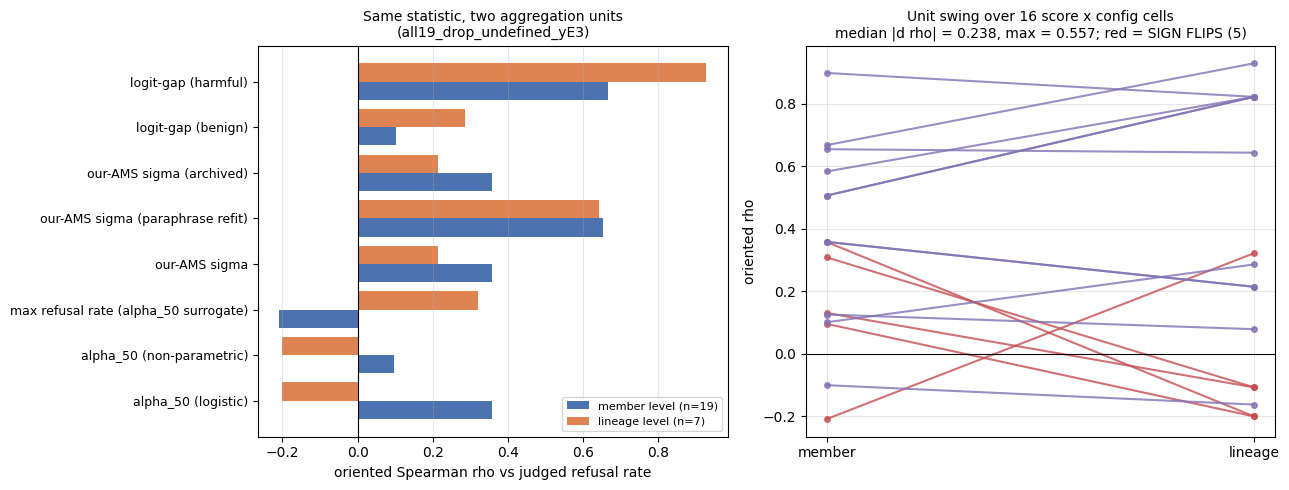

In [20]:
# ---- Figure: the aggregation unit alone moves the correlation ------------
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cfg_id = "all19_drop_undefined_yE3"
labels, rm, rl = [], [], []
for col in SCORE_COLUMNS:
    e = table[cfg_id]["scores"][col]
    a, b = e["member_level"]["rho_oriented"], e["lineage_level"]["rho_oriented"]
    if a is None or b is None:
        continue
    labels.append(SCORE_LABEL[col]); rm.append(a); rl.append(b)

ax = axes[0]
ypos = np.arange(len(labels))
ax.barh(ypos - 0.2, rm, height=0.4, label="member level (n=19)", color="#4C72B0")
ax.barh(ypos + 0.2, rl, height=0.4, label="lineage level (n=7)", color="#DD8452")
ax.set_yticks(ypos); ax.set_yticklabels(labels, fontsize=9)
ax.axvline(0, color="k", lw=0.8)
ax.set_xlabel("oriented Spearman rho vs judged refusal rate")
ax.set_title(f"Same statistic, two aggregation units\n({cfg_id})", fontsize=10)
ax.legend(fontsize=8); ax.grid(axis="x", alpha=0.3)

ax = axes[1]
for r in swing:
    c = "#C44E52" if r["sign_flips"] else "#8172B3"
    ax.plot([0, 1], [r["rho_member"], r["rho_lineage"]], "-o", color=c, alpha=0.8, ms=4)
ax.axhline(0, color="k", lw=0.8)
ax.set_xticks([0, 1]); ax.set_xticklabels(["member", "lineage"])
ax.set_ylabel("oriented rho")
ax.set_title(f"Unit swing over {len(swing)} score x config cells\n"
             f"median |d rho| = {sw['median_abs_change_in_rho']:.3f}, max = "
             f"{sw['max_abs_change_in_rho']:.3f}; red = SIGN FLIPS "
             f"({sw['n_cells_whose_sign_flips_with_the_unit']})", fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()